In [25]:
import pandas as pd
from shapely import wkt
from shapely.geometry import LineString
from pathlib import Path

# Create output folder
output_dir = Path('./pypsa_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# File paths
input_csv = 'csv/lines_aut.csv'
buses_csv = output_dir / 'buses.csv'
lines_csv = output_dir / 'lines.csv'

# Geometry simplification tolerance (in degrees)
simplify_tolerance = 0.001  # ~100 meters; adjust as needed

# Read input
df = pd.read_csv(input_csv, delimiter=';', quotechar='"', escapechar='\\')
df['geometry'] = df['geometry'].apply(wkt.loads)

# Containers
unique_points = {}  # (x, y) -> bus_id
bus_rows = []
line_rows = []
bus_id_counter = [0]  # mutable container to simulate nonlocal

# Helper to get or assign bus_id
def get_bus_id(x, y):
    key = (round(x, 5), round(y, 5))
    if key not in unique_points:
        bus_id = f'bus{bus_id_counter[0]}'
        unique_points[key] = bus_id
        bus_rows.append({
            'bus': bus_id,
            'x': x,
            'y': y
        })
        bus_id_counter[0] += 1
    return unique_points[key]

# Process each line
for idx, row in df.iterrows():
    line: LineString = row['geometry'].simplify(simplify_tolerance, preserve_topology=True)
    coords = list(line.coords)
    
    if len(coords) < 2:
        continue  # Skip invalid lines
    
    # Use first and last point of simplified line as connection points
    x0, y0 = coords[0]
    x1, y1 = coords[-1]
    
    bus0 = get_bus_id(x0, y0)
    bus1 = get_bus_id(x1, y1)
    
    # Optional: calculate length (approximate, in degrees)
    length = line.length
    
    line_rows.append({
        'name': f'line{idx}',
        'bus0': bus0,
        'bus1': bus1,
        'length': length,
        'geometry': line.wkt
    })

# Export CSVs
pd.DataFrame(bus_rows).to_csv(buses_csv, index=False)
pd.DataFrame(line_rows).to_csv(lines_csv, index=False)

print(f"✅ Exported {len(bus_rows)} buses and {len(line_rows)} lines to ./pypsa_csv/")


✅ Exported 1751 buses and 1434 lines to ./pypsa_csv/


## Check with pypsa

In [29]:
import pypsa

In [30]:
n = pypsa.Network()

n.import_from_csv_folder("pypsa_csv")

INFO:pypsa.io:Imported network pypsa_csv has buses, lines


In [32]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,geometry
Line,,,,,,,,,,,,,,,,,,,,,
line0,bus0,bus1,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (377942.1076980555 480212.212956966...
line1,bus2,bus3,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (381270.4640343237 484013.966387739...
line2,bus4,bus5,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (378019.55221694463 480229.43378805...
line3,bus5,bus6,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (381223.1867113711 484087.493142226...
line4,bus7,bus8,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (666823.4203998836 444499.181934626...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
line1429,bus1744,bus1745,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (661696.2612887365 457146.354202594...
line1430,bus1746,bus1747,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (629540.5105981105 473863.596975464...
line1431,bus1748,bus1538,,0.0,0.0,0.0,0.0,0.0,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LINESTRING (622818.664809231 376648.4908801422...


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


ValueError: Axis limits cannot be NaN or Inf

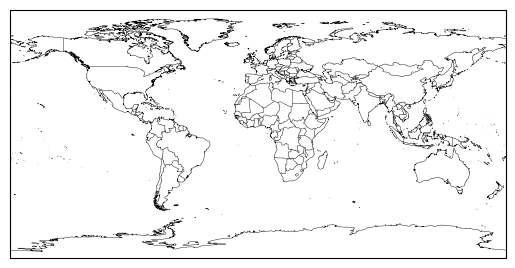

In [21]:
n.plot()